In [24]:
import zipfile

with zipfile.ZipFile("/content/movie.zip", "r") as zip_ref:
    zip_ref.extractall("/content/movie_dataset")

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [25]:
import os

for root, dirs, files in os.walk("/content/movie_dataset"):
    print(root)
    for file in files:
        print(file)

/content/movie_dataset
/content/movie_dataset/Genre Classification Dataset
description.txt
train_data.txt
test_data.txt
test_data_solution.txt


In [26]:
import pandas as pd

train = pd.read_csv(
    "/content/movie_dataset/Genre Classification Dataset/train_data.txt",
    sep=":::",
    engine="python",
    names=["ID", "Genre", "Description"]
)

test = pd.read_csv(
    "/content/movie_dataset/Genre Classification Dataset/test_data.txt",
    sep=":::",
    engine="python",
    names=["ID", "Description"]
)

print(train.head())

                                   ID       Genre  \
1       Oscar et la dame rose (2009)       drama    
2                       Cupid (1997)    thriller    
3   Young, Wild and Wonderful (1980)       adult    
4              The Secret Sin (1915)       drama    
5             The Unrecovered (2007)       drama    

                                         Description  
1   Listening in to a conversation between his do...  
2   A brother and sister with a past incestuous r...  
3   As the bus empties the students for their fie...  
4   To help their unemployed father make ends mee...  
5   The film's title refers not only to the un-re...  


In [27]:
print(train.shape)
print(train.columns)
print(train.isnull().sum())
print(train["Genre"].value_counts())

(54214, 3)
Index(['ID', 'Genre', 'Description'], dtype='object')
ID             0
Genre          0
Description    0
dtype: int64
Genre
drama           13613
documentary     13096
comedy           7447
short            5073
horror           2204
thriller         1591
action           1315
western          1032
reality-tv        884
family            784
adventure         775
music             731
romance           672
sci-fi            647
adult             590
crime             505
animation         498
sport             432
talk-show         391
fantasy           323
mystery           319
musical           277
biography         265
history           243
game-show         194
news              181
war               132
Name: count, dtype: int64


In [28]:
import re

train["Description"] = train["Description"].str.lower()

train["Description"] = train["Description"].apply(
    lambda x: re.sub(r"[^a-zA-Z ]", "", str(x))
)

print(train["Description"].head())



1     listening in to a conversation between his do...
2     a brother and sister with a past incestuous r...
3     as the bus empties the students for their fie...
4     to help their unemployed father make ends mee...
5     the films title refers not only to the unreco...
Name: Description, dtype: object


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(train["Description"])

y = train["Genre"]

print(X.shape)

(54214, 5000)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(43371, 5000)
(10843, 5000)


In [31]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [32]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.5100064557779213
               precision    recall  f1-score   support

      action        0.57      0.05      0.08       263
       adult        1.00      0.02      0.04       112
   adventure        0.33      0.02      0.04       139
   animation        0.00      0.00      0.00       104
   biography        0.00      0.00      0.00        61
      comedy        0.50      0.39      0.44      1443
       crime        0.00      0.00      0.00       107
 documentary        0.57      0.89      0.69      2659
       drama        0.44      0.83      0.58      2697
      family        0.00      0.00      0.00       150
     fantasy        0.00      0.00      0.00        74
   game-show        1.00      0.03      0.05        40
     history        0.00      0.00      0.00        45
      horror        0.75      0.26      0.39       431
       music        0.93      0.10      0.18       144
     musical        0.00      0.00      0.00        50
     mystery        0.00      0.00 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


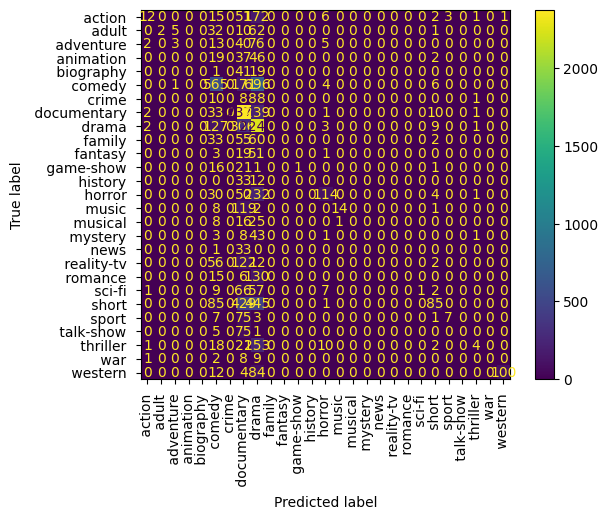

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90
)

plt.show()

In [34]:
sample = [
    "A brave police officer fights dangerous criminals to save the city."
]

sample_vector = tfidf.transform(sample)

prediction = model.predict(sample_vector)

print("Predicted Genre:", prediction[0])

Predicted Genre:  drama 
